In [126]:
%config IPCompleter.use_jedi = True  # or False if Jedi is buggy with your libs
%config Completer.use_jedi = True
%config IPCompleter.greedy = True  # For nested completion like obj.attr1.attr2


In [127]:
import numpy as np 
import pandas as pd 

In [128]:
email = pd.read_csv('../emailspam/email.csv')

In [129]:
email.shape

(5573, 2)

In [130]:
email.sample(5)

,Category,Message
3336,ham,"Sorry, got a late start, we're on the way"
99,ham,I see a cup of coffee animation
4299,spam,WELL DONE! Your 4* Costa Del Sol Holiday or £5...
5377,spam,The current leading bid is 151. To pause this ...
331,ham,K.k:)apo k.good movie.


In [131]:
email.info

<bound method DataFrame.info of             Category                                            Message
0                ham  Go until jurong point, crazy.. Available only ...
1                ham                      Ok lar... Joking wif u oni...
2               spam  Free entry in 2 a wkly comp to win FA Cup fina...
3                ham  U dun say so early hor... U c already then say...
4                ham  Nah I don't think he goes to usf, he lives aro...
...              ...                                                ...
5568             ham               Will ü b going to esplanade fr home?
5569             ham  Pity, * was in mood for that. So...any other s...
5570             ham  The guy did some bitching but I acted like i'd...
5571             ham                         Rofl. Its true to its name
5572  {"mode":"full"                                    isActive:false}

[5573 rows x 2 columns]>

In [132]:
email.rename(columns={'Category':'Issspam'},inplace=True)


In [133]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()


In [134]:
email.Issspam = encoder.fit_transform(email['Issspam'])

In [135]:
email.sample(10)

,Issspam,Message
2006,0,Can't take any major roles in community outrea...
4817,0,Anything is valuable in only 2 situations: Fir...
3730,0,I'm at home. Please call
2910,1,URGENT! Your Mobile number has been awarded wi...
2138,0,Then why you came to hostel.
3673,0,"came to look at the flat, seems ok, in his 50s..."
4167,0,Well if I'm that desperate I'll just call arma...
4898,0,I cant pick the phone right now. Pls send a me...
3204,0,Haha... Yup hopefully we will lose a few kg b...
2340,0,Cheers for the message Zogtorius. Ive been st...


In [136]:
email.duplicated().sum()

np.int64(415)

In [137]:
email = email.drop_duplicates(keep='first')
email.duplicated().sum()

np.int64(0)

In [138]:
email.Issspam.value_counts()

Issspam
0    4516
1     641
2       1
Name: count, dtype: int64

In [139]:
email.drop(email[email.Issspam==2].index,inplace=True)
email.Issspam.value_counts()

/tmp/ipykernel_7830/3598660158.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  email.drop(email[email.Issspam==2].index,inplace=True)


Issspam
0    4516
1     641
Name: count, dtype: int64

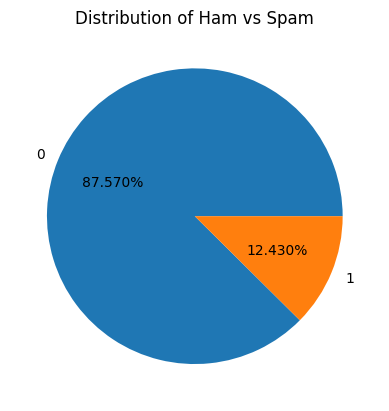

In [140]:
import matplotlib.pyplot as plt


counts = email['Issspam'].value_counts()
labels = counts.index 

# Plot pie chart
plt.pie(counts, labels=labels, autopct="%0.3f%%")
plt.title("Distribution of Ham vs Spam")
plt.show()


In [ ]:
from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer(r'\w+')
import nltk
from typing import List

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /home/aaron/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [142]:
email['letterlen'] = email.Message.apply(len)

/tmp/ipykernel_7830/693664644.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  email['letterlen'] = email.Message.apply(len)


In [143]:
email['numwords'] = email.Message.apply(lambda x:len(tokenizer.tokenize(x)))

/tmp/ipykernel_7830/3166859425.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  email['numwords'] = email.Message.apply(lambda x:len(tokenizer.tokenize(x)))


In [144]:
email['Senlen'] = email.Message.apply(lambda x:len(nltk.sent_tokenize(x)))

/tmp/ipykernel_7830/1934115864.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  email['Senlen'] = email.Message.apply(lambda x:len(nltk.sent_tokenize(x)))


In [ ]:
email.head()

,Issspam,Message,letterlen,numwords,Senlen
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,33,2
3,0,U dun say so early hor... U c already then say...,49,11,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,14,1


<Axes: xlabel='letterlen', ylabel='Count'>

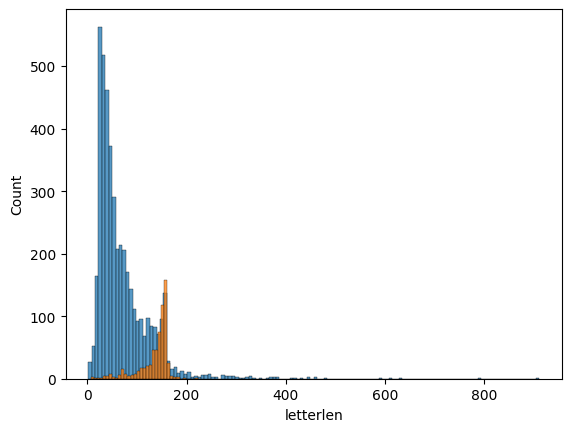

In [146]:
import seaborn as sns 

sns.histplot(email[email.Issspam==0]['letterlen'])
sns.histplot(email[email.Issspam==1]['letterlen'])

<Axes: xlabel='numwords', ylabel='Count'>

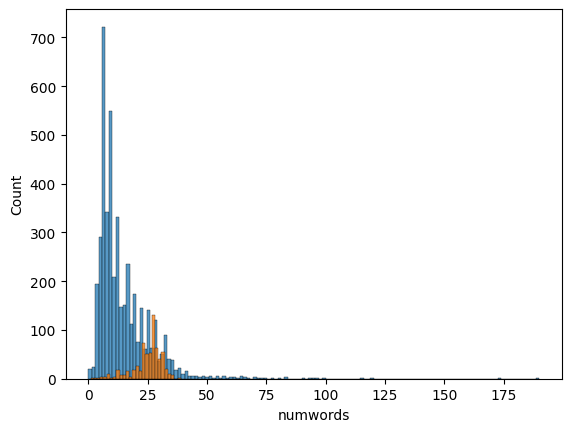

In [147]:

sns.histplot(email[email.Issspam==0]['numwords'])
sns.histplot(email[email.Issspam==1]['numwords'])

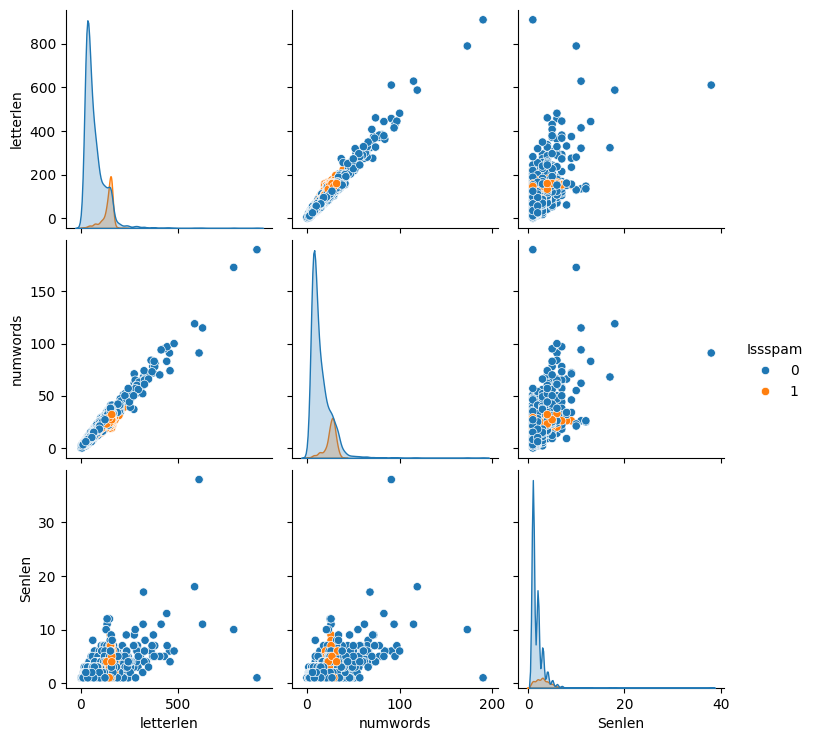

In [148]:
sns.pairplot(email,hue='Issspam')

<Axes: >

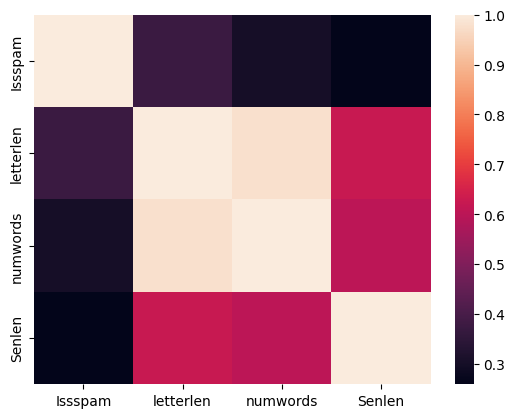

In [149]:
corrs = email.drop(columns='Message').corr()
sns.heatmap(corrs)

In [ ]:
from nltk.corpus import stopwords
from copy import deepcopy
import string
stoppingwords = stopwords.words('english')
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()


def transformtext(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    strings=[]
    for i in text:
        if i.isalnum():
            strings.append(i)

    text=strings[:]
    strings.clear()

    for i in text:
        if i not in stoppingwords and i not in string.punctuation: 
            strings.append(i) 

    text=strings[:]
    strings.clear()

    for i in text:
        strings.append(ps.stem(i))
    
    return ' '.join(strings)

In [151]:
txt ="Wasgood my babies how u love loving loves!! "


In [152]:
transformtext(txt)

'wasgood babi u love love love'

In [153]:
email['transformed_text'] = email.Message.apply(transformtext)

/tmp/ipykernel_7830/2552908711.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  email['transformed_text'] = email.Message.apply(transformtext)


In [154]:
email.transformed_text

0       go jurong point crazi avail bugi n great world...
1                                   ok lar joke wif u oni
2       free entri 2 wkli comp win fa cup final tkt 21...
3                     u dun say earli hor u c alreadi say
4                    nah think goe usf live around though
                              ...                        
5567    2nd time tri 2 contact u pound prize 2 claim e...
5568                              ü b go esplanad fr home
5569                                    piti mood suggest
5570    guy bitch act like interest buy someth els nex...
5571                                       rofl true name
Name: transformed_text, Length: 5157, dtype: object

In [155]:
email.head(5)

,Issspam,Message,letterlen,numwords,Senlen,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,33,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,14,1,nah think goe usf live around though


In [156]:
from pyparsing import Word
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500 , min_font_size=10, background_color='white')

In [157]:
from os import sep


spam_wc = wc.generate(email[email['Issspam']==1]['transformed_text'].str.cat(sep=" "))

ham_wc = wc.generate(email[email['Issspam']==0]['transformed_text'].str.cat(sep=" "))

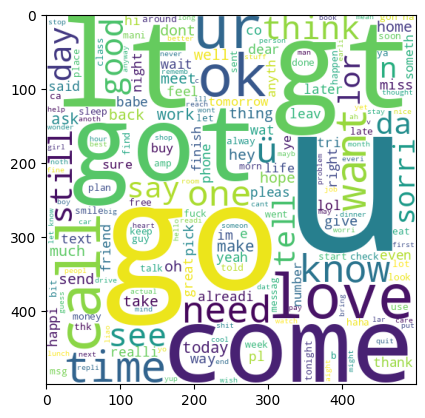

In [158]:
plt.imshow(spam_wc)


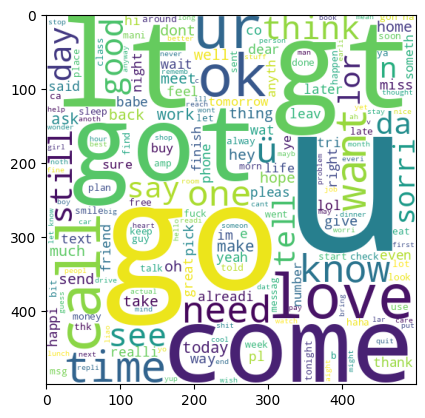

In [159]:
plt.imshow(ham_wc)


In [160]:
spamcorpus=[]
for i in email[email.Issspam==1].transformed_text.to_list():
    for word in i.split():
        spamcorpus.append(word)

In [161]:

from collections import Counter
datacounter = Counter(spamcorpus).most_common(30)
datacounter = pd.DataFrame(datacounter)
datacounter.head()
datacounter.columns = ['word', 'count']


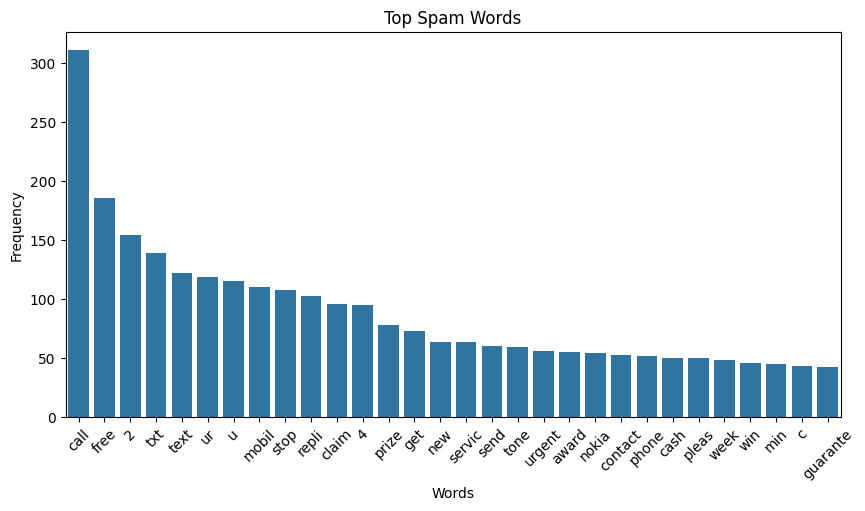

In [162]:
plt.figure(figsize=(10, 5))
sns.barplot(x='word', y='count', data=datacounter)
plt.title("Top Spam Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)  # Rotate for better readability
plt.show()

In [163]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tf = TfidfVectorizer(max_features=3000)

In [164]:
X = tf.fit_transform(email.transformed_text).toarray()
X.shape


(5157, 3000)

In [165]:
Y = email.Issspam.values
Y

array([0, 0, 1, ..., 0, 0, 0], shape=(5157,))

In [166]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,Ytrain,Ytest =train_test_split(X,Y,test_size=0.2,random_state=12)


In [167]:

from sklearn.metrics import confusion_matrix,accuracy_score,precision_score

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB  # or BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Ensemble models
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

In [168]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "SVM": SVC(kernel='linear'),  # faster
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "MultinomialNB": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=10),
    "Random Forest": RandomForestClassifier(n_estimators=50),
    "AdaBoost": AdaBoostClassifier(n_estimators=50),
    "Bagging": BaggingClassifier(n_estimators=30),
    "Extra Trees": ExtraTreesClassifier(n_estimators=50),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50),
}


In [169]:



results = pd.DataFrame()

In [170]:
results = []
trained_models = {}
for name, model in models.items():
    model.fit(Xtrain, Ytrain)
    ypred = model.predict(Xtest)
    
    acc = accuracy_score(Ytest, ypred)
    prec = precision_score(Ytest, ypred)
    
    trained_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec
    })



In [171]:
results
comparingresult=pd.DataFrame(results)
trained_models["Random Forest"]

RandomForestClassifier(n_estimators=50)

In [172]:
comparingresult.sort_values("Precision",ascending=False)

,Model,Accuracy,Precision
5,Random Forest,0.977713,1.000000
2,KNN,0.923450,1.000000
1,SVM,0.983527,0.991150
8,Extra Trees,0.981589,0.982301
3,MultinomialNB,0.974806,0.981132
0,Logistic Regression,0.955426,0.965909
9,Gradient Boosting,0.952519,0.943820
7,Bagging,0.965116,0.889831
4,Decision Tree,0.957364,0.888889
6,AdaBoost,0.915698,0.746988


In [173]:
RF = RandomForestClassifier(n_estimators=50)
RF.fit(Xtrain,Ytrain)
RFpred = RF.predict(Xtest)
acc = accuracy_score(Ytest, RFpred)
prec = precision_score(Ytest, RFpred)



In [174]:
prec

1.0

In [175]:
import pickle

# Save vectorizer
with open('vectorizer_pickle.pkl', 'wb') as f:
    pickle.dump(tf, f)

# Save classifier model (Random Forest, etc.)
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(trained_models["Random Forest"],f)
